# IHK Gewerbedaten: Exploration

## Load packages + data

In [12]:
#load packages
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [ ]:
#data: yearly IHK panel
ihk_df = pd.read_csv("/Users/mareikesahling/Ginger_Gradient/Capstone/capstone-kiezkeeper/data/IHK_Berlin_Gewerbedaten/analysis_ready_data/yearly_panel_merged.csv",
                       dtype={"planungsraum_id": str, "year": str})

#geo info and districts 
import pandas as pd

info_df = pd.read_csv("/Users/mareikesahling/Ginger_Gradient/Capstone/capstone-kiezkeeper/data/IHK_Berlin_Gewerbedaten/intermediate_data/2024_05_IHK_Berlin_Gewerbedaten.csv",
    dtype={"planungsraum_id": str},
    usecols=["planungsraum_id", "Bezirk", "Bezirksregion", "Prognoseraum", "Planungsraum", "Ortsteil"],
).drop_duplicates("planungsraum_id")

print(info_df.shape)   # 542 rows, one per plr

(542, 6)


In [47]:
#geodaten
url = ("https://gdi.berlin.de/services/wfs/lor_2021"
       "?service=WFS&version=2.0.0&request=GetFeature"
       "&typeNames=lor_2021:a_lor_plr_2021&outputFormat=application/json")
plr = gpd.read_file(url)[["plr_id", "plr_name", "bez", "geometry"]]
plr = plr.rename(columns={"plr_id": "planungsraum_id"})
print(plr.head())

  planungsraum_id           plr_name         bez  \
0        01100101       Stülerstraße  01 - Mitte   
1        01100102  Großer Tiergarten  01 - Mitte   
2        01100103       Lützowstraße  01 - Mitte   
3        01100104       Körnerstraße  01 - Mitte   
4        01100205      Wilhelmstraße  01 - Mitte   

                                            geometry  
0  MULTIPOLYGON (((387734.049 5818805.749, 387730...  
1  MULTIPOLYGON (((388844.543 5818534.703, 388846...  
2  MULTIPOLYGON (((388844.543 5818534.703, 388837...  
3  MULTIPOLYGON (((389230.797 5818563.08, 389211....  
4  MULTIPOLYGON (((390574.963 5819009.485, 390569...  


In [33]:
ihk_df = ihk_df.merge(info_df, on="planungsraum_id", how="left")
ihk_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2168 entries, 0 to 2167
Data columns (total 54 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   planungsraum_id          2168 non-null   object 
 1   year                     2168 non-null   object 
 2   n_total                  2168 non-null   float64
 3   n_with_age               2168 non-null   float64
 4   n_age_missing            2168 non-null   float64
 5   median_age               2168 non-null   float64
 6   share_max_1y             2168 non-null   float64
 7   share_max_2y             2168 non-null   float64
 8   share_max_5y             2168 non-null   float64
 9   share_min_20y            2168 non-null   float64
 10  share_min_30y            2168 non-null   float64
 11  share_min_40y            2168 non-null   float64
 12  n_known_size             2168 non-null   float64
 13  n_size_unknown           2168 non-null   float64
 14  share_solo              

In [ ]:
#missing values for the 18 plr without gastro establishments 
ihk_df.isna().sum()

planungsraum_id             0
year                        0
n_total                     0
n_with_age                  0
n_age_missing               0
median_age                  0
share_max_1y                0
share_max_2y                0
share_max_5y                0
share_min_20y               0
share_min_30y               0
share_min_40y               0
n_known_size                0
n_size_unknown              0
share_solo                  0
share_1_9                   0
share_10plus                0
n_large                     0
n_gastro                    0
n_upscale                   0
gastro_share                0
upscale_share              18
gastro_quotient_bezirk      0
gastro_quotient_berlin      0
upscale_quotient_bezirk    18
upscale_quotient_berlin    18
n_tourism                   0
tourism_share               0
tourism_quotient_bezirk     0
tourism_quotient_berlin     0
n_upscale_max_1y            0
n_upscale_max_2y            0
n_upscale_max_5y            0
share_upsc

## EDA

<Axes: >

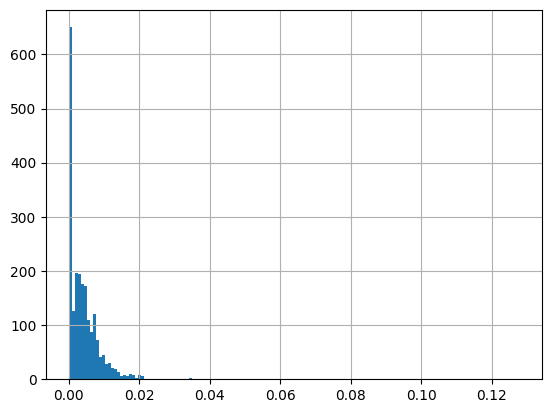

In [ ]:
#look at tourism share variable
ihk_df['tourism_share'].hist(bins = 150)

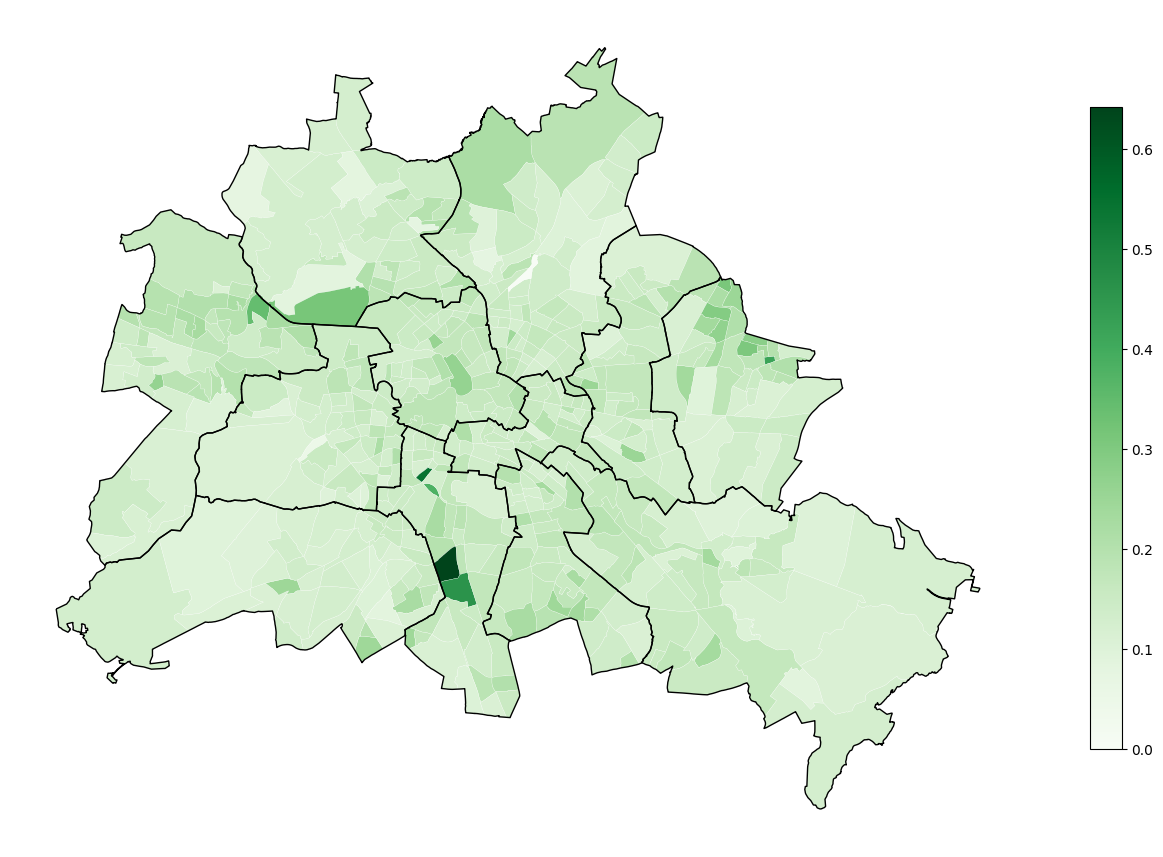

In [68]:
import matplotlib.pyplot as plt

# Bezirksgrenzen aus den PLR-Polygonen (einmal, falls noch nicht vorhanden)
bezirke = plr.dissolve(by="bez").reset_index()

# Daten 2026 an die Geometrie joinen
data = ihk_df[ihk_df["year"] == "2024"]
karte = plr.merge(data, on="planungsraum_id", how="left")

fig, ax = plt.subplots(figsize=(13, 11))
karte.plot(column="entry_rate", cmap="Greens", legend=True, ax=ax,
           edgecolor="white", linewidth=0.15,
           missing_kwds={"color": "lightgrey", "label": ""},
           legend_kwds={"shrink": 0.6, "label": ""})
bezirke.boundary.plot(ax=ax, color="black", linewidth=1.0)

ax.set_title("")
ax.axis("off"); plt.tight_layout(); plt.show()

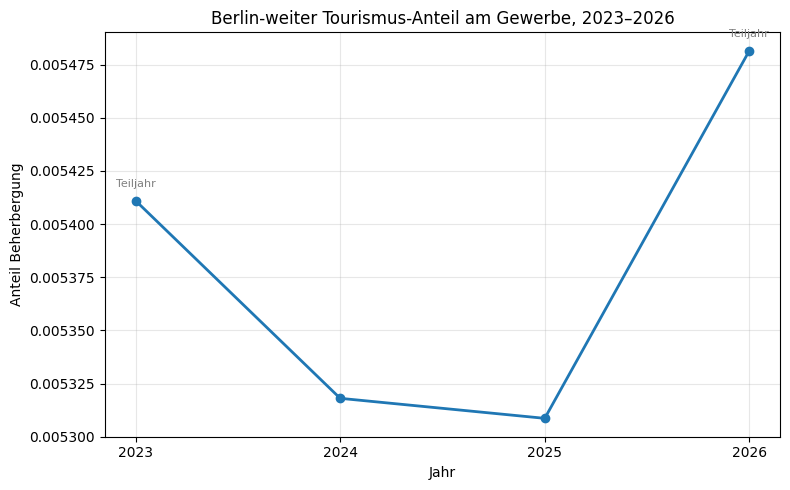

In [43]:
berlin = (ihk_df.groupby("year")
            .apply(lambda g: g["n_tourism"].sum() / g["n_total"].sum())
            .rename("tourism_share_berlin"))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(berlin.index, berlin.values, marker="o", linewidth=2)
ax.set_title("Berlin-weiter Tourismus-Anteil am Gewerbe, 2023–2026")
ax.set_xlabel("Jahr"); ax.set_ylabel("Anteil Beherbergung")
ax.grid(alpha=0.3)
# Teiljahre markieren
for y in ["2023", "2026"]:
    ax.annotate("Teiljahr", (y, berlin[y]), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=8, color="grey")
plt.tight_layout(); plt.show()

In [ ]:
#plr with highest tourism share
ihk_df.groupby

In [ ]:
#plot plr with highest churn rates per year



planungsraum_id
01100101     10.895833
01100102    119.520833
01100103     41.333333
01100104     31.083333
01100205    101.604167
               ...    
12601032     16.083333
12601133      5.541667
12601134     23.291667
12601235      3.541667
12601236      9.770833
Name: n_gastro, Length: 542, dtype: float64

In [16]:
import geopandas as gpd

url = ("https://gdi.berlin.de/services/wfs/lor_2021"
       "?service=WFS&version=2.0.0&request=GetFeature"
       "&typeNames=lor_2021:a_lor_plr_2021&outputFormat=application/json")
plr = gpd.read_file(url)
print(plr.shape)        # sollte 542 Zeilen sein
print(plr.columns.tolist())
print(plr.head())

(542, 13)
['id', 'plr_id', 'plr_name', 'bzr_id', 'bzr_name', 'pgr_id', 'pgr_name', 'bez', 'finhalt', 'stadtraum_id', 'stadtraum_name', 'stand', 'geometry']
                        id    plr_id           plr_name  bzr_id  \
0  a_lor_plr_2021.01100101  01100101       Stülerstraße  011001   
1  a_lor_plr_2021.01100102  01100102  Großer Tiergarten  011001   
2  a_lor_plr_2021.01100103  01100103       Lützowstraße  011001   
3  a_lor_plr_2021.01100104  01100104       Körnerstraße  011001   
4  a_lor_plr_2021.01100205  01100205      Wilhelmstraße  011002   

            bzr_name pgr_id pgr_name         bez       finhalt stadtraum_id  \
0     Tiergarten Süd   0110  Zentrum  01 - Mitte  3.669331e+05            1   
1     Tiergarten Süd   0110  Zentrum  01 - Mitte  3.919852e+06            1   
2     Tiergarten Süd   0110  Zentrum  01 - Mitte  5.471832e+05            1   
3     Tiergarten Süd   0110  Zentrum  01 - Mitte  3.385139e+05            1   
4  Regierungsviertel   0110  Zentrum  01 - Mit

## Loading & Basic Cleaning

In [100]:
#load dataset
df = pd.read_csv("/Users/mareikesahling/Ginger_Gradient/Capstone/capstone-kiezkeeper/data/IHK_Berlin_Gewerbedaten/intermediate_data/2024_07_IHK_Berlin_Gewerbedaten.csv",dtype={"opendata_id": str, "planungsraum_id": str}, low_memory=False)

In [96]:
meta = pd.read_csv("/Users/mareikesahling/Ginger_Gradient/Capstone/capstone-kiezkeeper/data/IHK_Berlin_Gewerbedaten/enriched_data/stage3_enrich_meta.csv")

In [85]:
churn = pd.read_csv(("/Users/mareikesahling/Ginger_Gradient/Capstone/capstone-kiezkeeper/data/IHK_Berlin_Gewerbedaten/analysis_ready_data/churn_panel.csv"))

In [88]:
churn.dtypes

planungsraum_id           int64
month                    object
n_prev                  float64
n_curr                    int64
entries                 float64
exits                   float64
movers_in               float64
movers_out              float64
entry_rate              float64
exit_rate               float64
churn_rate              float64
churn_rate_exclusive    float64
dtype: object

In [90]:
wz_2008 = pd.read_csv("/Users/mareikesahling/Ginger_Gradient/Capstone/capstone-kiezkeeper/data/IHK_Berlin_Gewerbedaten/intermediate_data/WZ2008_categories_until_may2025.csv")

In [91]:
wz_2008.head()

,ihk_branch_id,ihk_branch_desc,Bewertung,Touristifizierung,Begründung,Abteilung,Gruppe,Klasse,Ebene
0,55,Beherbergung,NaN,NaN,Abteilungsebene (Sammelcode),55,NaN,NaN,Abteilung
1,551,"Hotels, Gasthöfe u. Pensionen",NaN,relevant,Hotel/Pension – touristifizierungsrelevant,55,55.1,NaN,Gruppe
2,5510,"Hotels, Gasthöfe u. Pensionen",NaN,relevant,Hotel/Pension – touristifizierungsrelevant,55,55.1,55.1,Klasse
3,55101,Hotels (ohne Hotels garnis),NaN,relevant,Hotel/Pension – touristifizierungsrelevant,55,55.1,55.1,Unterklasse
4,55102,Hotels garnis,NaN,relevant,Hotel/Pension – touristifizierungsrelevant,55,55.1,55.1,Unterklasse


In [101]:
df['employees_range'].value_counts()

employees_range
0 Beschäftigte                 232963
1 - 3 Beschäftigte              83666
4 - 6 Beschäftigte              13720
unbekannt                        9222
10 - 19 Beschäftigte             8318
7 - 9 Beschäftigte               5867
20 - 49 Beschäftigte             5761
50 - 99 Beschäftigte             2057
100 - 199 Beschäftigte           1054
200 - 499 Beschäftigte            656
500 - 999 Beschäftigte            185
1000 - 2499 Beschäftigte          107
2500 - 4999 Beschäftigte           32
5000 - 7499 Beschäftigte           10
7500 - 9999 Beschäftigte            7
10000 und mehr Beschäftigte         6
Name: count, dtype: int64

In [89]:
churn.tail(10)

,planungsraum_id,month,n_prev,n_curr,entries,exits,movers_in,movers_out,entry_rate,exit_rate,churn_rate,churn_rate_exclusive
19502,12500927,2026-06,709.0,706,5.0,8.0,1.0,3.0,0.007067,0.011307,0.018375,0.012721
19503,12500928,2026-06,603.0,613,15.0,5.0,2.0,1.0,0.024671,0.008224,0.032895,0.027961
19504,12500929,2026-06,341.0,337,1.0,5.0,0.0,1.0,0.002950,0.014749,0.017699,0.014749
19505,12500930,2026-06,367.0,365,4.0,6.0,1.0,1.0,0.010929,0.016393,0.027322,0.021858
19506,12601031,2026-06,385.0,388,7.0,4.0,1.0,2.0,0.018111,0.010349,0.028461,0.020699
19507,12601032,2026-06,253.0,256,6.0,3.0,1.0,0.0,0.023576,0.011788,0.035363,0.031434
19508,12601133,2026-06,366.0,370,6.0,2.0,2.0,1.0,0.016304,0.005435,0.021739,0.013587
19509,12601134,2026-06,493.0,493,10.0,10.0,1.0,3.0,0.020284,0.020284,0.040568,0.032454
19510,12601235,2026-06,288.0,290,6.0,4.0,0.0,1.0,0.020761,0.013841,0.034602,0.031142
19511,12601236,2026-06,176.0,176,1.0,1.0,0.0,0.0,0.005682,0.005682,0.011364,0.011364


In [99]:
meta['gastro_unmapped'].value_counts()

gastro_unmapped
0    36
Name: count, dtype: int64

In [52]:
df.sample(6) 

,opendata_id,city,postcode,latitude,longitude,ihk_branch_id,nace_id,branch_top_level_id,employees_range,ihk_branch_desc,nace_desc,branch_top_level_desc,business_age,business_type,Bezirk,planungsraum_id,Planungsraum,Bezirksregion,Prognoseraum,Ortsteil
157905,98243947798,Berlin,10117,52.511163,13.391491,7490010.0,7490.0,74.0,20 - 49 Beschäftigte,Vermögensverwaltung,"Sonstige freiberufliche, wissenschaftliche u. ...","Sonstige freiberufliche, wissenschaftliche u. ...",7.0,im Handelsregister eingetragen,Mitte,01100207,Leipziger Straße,Regierungsviertel,Zentrum,Mitte
361518,1289859671532,Berlin,10367,52.516923,13.482352,47510.0,4751.0,47.0,0 Beschäftigte,EH m. Textilien,EH m. Textilien,Einzelhandel (ohne Handel mit Kraftfahrzeugen),0.0,Kleingewerbetreibender,Lichtenberg,11300722,Rathaus Lichtenberg,Alt-Lichtenberg,Lichtenberg Nord,Lichtenberg
354084,13302042714,Berlin,12159,52.469178,13.333481,821100.0,8211.0,82.0,0 Beschäftigte,Büroservice,Allgemeine Sekretariats- u. Schreibdienste,Erbringung v. wirtschaftlichen Dienstleistunge...,0.0,Kleingewerbetreibender,Steglitz-Zehlendorf,07300618,Ceciliengärten,Friedenau Ost,Friedenau,Friedenau
210997,111130747358,Berlin,10829,52.482005,13.367550,64200.0,6420.0,64.0,1 - 3 Beschäftigte,Beteiligungsgesellschaften,Beteiligungsgesellschaften,Erbringung v. Finanzdienstleistungen,5.0,im Handelsregister eingetragen,Tempelhof-Schöneberg,07200413,Cheruskerstraße,Schöneberg Südost,Schöneberg Süd,Schöneberg
68123,632981471938,Berlin,13407,52.568826,13.345187,662200.0,6622.0,66.0,0 Beschäftigte,Versicherungsvertreter,Tätigkeit v. Versicherungsmaklerinnen u. -maklern,Mit Finanz- u. Versicherungsdienstleistungen v...,15.0,Kleingewerbetreibender,Reinickendorf,12100205,Teichstraße,Ost 2 - Alt-Reinickendorf,Reinickendorf Ost,Reinickendorf
56745,1319827271424,Berlin,12681,52.528582,13.523816,62019.0,6201.0,62.0,0 Beschäftigte,Sonstige Softwareentwicklung,Programmierungstätigkeiten,Erbringung v. Dienstleistungen der Information...,0.0,im Handelsregister eingetragen,Marzahn-Hellersdorf,10100311,Marzahner Chaussee,Marzahn Süd,Marzahn,Marzahn


In [84]:
df.isna().sum()

opendata_id                0
city                       0
postcode                   0
latitude                   0
longitude                  0
ihk_branch_id             77
nace_id                   77
branch_top_level_id       77
employees_range            0
ihk_branch_desc           77
nace_desc                180
branch_top_level_desc    133
business_age             885
business_type              0
Bezirk                     0
planungsraum_id            0
Planungsraum               0
Bezirksregion              0
Prognoseraum               0
Ortsteil                  11
dtype: int64

In [60]:
duplicates = df.loc[df['opendata_id'].duplicated()]
duplicates['opendata_id'].value_counts()

opendata_id
133329727324    11
133341007700    11
133336267542    11
133336447548    11
133336567552    11
                ..
133344727824    11
133344847828    11
133341967732    11
133341847728    11
133333687456    11
Name: count, Length: 264, dtype: int64

In [69]:
duplicates[duplicates['opendata_id'] == "133336267542"].sample(11)

,opendata_id,city,postcode,latitude,longitude,ihk_branch_id,nace_id,branch_top_level_id,employees_range,ihk_branch_desc,nace_desc,branch_top_level_desc,business_age,business_type,Bezirk,planungsraum_id,Planungsraum,Bezirksregion,Prognoseraum,Ortsteil
344268,133336267542,Berlin,10247,52.508177,13.470307,0.0,0.0,0.0,0 Beschäftigte,noch unbekannt,NaN,NaN,0.0,Kleingewerbetreibender,Treptow-Köpenick,02500832,Traveplatz,Frankfurter Allee Süd FK,Friedrichshain Ost,Friedrichshain
344136,133336267542,Berlin,10247,52.508177,13.470307,0.0,0.0,0.0,0 Beschäftigte,noch unbekannt,NaN,NaN,0.0,Kleingewerbetreibender,Pankow,02500832,Traveplatz,Frankfurter Allee Süd FK,Friedrichshain Ost,Friedrichshain
344232,133336267542,Berlin,10247,52.508177,13.470307,0.0,0.0,0.0,0 Beschäftigte,noch unbekannt,NaN,NaN,0.0,Kleingewerbetreibender,Friedrichshain-Kreuzberg,02500832,Traveplatz,Frankfurter Allee Süd FK,Friedrichshain Ost,Friedrichshain
344144,133336267542,Berlin,10247,52.508177,13.470307,0.0,0.0,0.0,0 Beschäftigte,noch unbekannt,NaN,NaN,0.0,Kleingewerbetreibender,Steglitz-Zehlendorf,02500832,Traveplatz,Frankfurter Allee Süd FK,Friedrichshain Ost,Friedrichshain
344243,133336267542,Berlin,10247,52.508177,13.470307,0.0,0.0,0.0,0 Beschäftigte,noch unbekannt,NaN,NaN,0.0,Kleingewerbetreibender,Neukölln,02500832,Traveplatz,Frankfurter Allee Süd FK,Friedrichshain Ost,Friedrichshain
344140,133336267542,Berlin,10247,52.508177,13.470307,0.0,0.0,0.0,0 Beschäftigte,noch unbekannt,NaN,NaN,0.0,Kleingewerbetreibender,Tempelhof-Schöneberg,02500832,Traveplatz,Frankfurter Allee Süd FK,Friedrichshain Ost,Friedrichshain
344229,133336267542,Berlin,10247,52.508177,13.470307,0.0,0.0,0.0,0 Beschäftigte,noch unbekannt,NaN,NaN,0.0,Kleingewerbetreibender,Marzahn-Hellersdorf,02500832,Traveplatz,Frankfurter Allee Süd FK,Friedrichshain Ost,Friedrichshain
344169,133336267542,Berlin,10247,52.508177,13.470307,0.0,0.0,0.0,0 Beschäftigte,noch unbekannt,NaN,NaN,0.0,Kleingewerbetreibender,Spandau,02500832,Traveplatz,Frankfurter Allee Süd FK,Friedrichshain Ost,Friedrichshain
344206,133336267542,Berlin,10247,52.508177,13.470307,0.0,0.0,0.0,0 Beschäftigte,noch unbekannt,NaN,NaN,0.0,Kleingewerbetreibender,Mitte,02500832,Traveplatz,Frankfurter Allee Süd FK,Friedrichshain Ost,Friedrichshain
344261,133336267542,Berlin,10247,52.508177,13.470307,0.0,0.0,0.0,0 Beschäftigte,noch unbekannt,NaN,NaN,0.0,Kleingewerbetreibender,Lichtenberg,02500832,Traveplatz,Frankfurter Allee Süd FK,Friedrichshain Ost,Friedrichshain


In [70]:
dup_ids = df.loc[df["opendata_id"].duplicated(keep=False), "opendata_id"]
sub = df[df["opendata_id"].isin(dup_ids)]
for col in ["Bezirk", "Bezirksregion", "Prognoseraum", "Planungsraum", "Ortsteil"]:
    n_varying = (sub.groupby("opendata_id")[col].nunique() > 1).sum()
    print(f"{col}: {n_varying} ids mit mehreren Werten")

Bezirk: 264 ids mit mehreren Werten
Bezirksregion: 0 ids mit mehreren Werten
Prognoseraum: 0 ids mit mehreren Werten
Planungsraum: 0 ids mit mehreren Werten
Ortsteil: 0 ids mit mehreren Werten


In [43]:
df.duplicated().sum()

0

In [35]:
meta = pd.read_csv("/Users/mareikesahling/Ginger_Gradient/Capstone/capstone-kiezkeeper/data/IHK_Berlin_Gewerbedaten/intermediate_data/stage1_cleaning_meta.csv")

In [36]:
meta.head()

,source_file,month,rows_before,rows_after,rows_dropped,written,dropped_missing_opendata_id,dropped_missing_planungsraum_id,missing_opendata_id,missing_city,...,missing_Planungsraum,missing_Bezirksregion,missing_Prognoseraum,missing_Ortsteil,opendata_id_non_integer,postcode_non_integer,ihk_branch_id_non_integer,nace_id_non_integer,branch_top_level_id_non_integer,planungsraum_id_bad_width
0,2023_07_IHK_Berlin_Gewerbedaten.csv,2023-07,351869,351181,688,True,0,688,0,0,...,688,688,688,28,0,0,0,0,0,0
1,2023_08_IHK_Berlin_Gewerbedaten.csv,2023-08,353330,352640,690,True,0,690,0,0,...,690,690,690,30,0,0,0,0,0,0
2,2023_09_IHK_Berlin_Gewerbedaten.csv,2023-09,354904,354212,692,True,0,692,0,0,...,692,692,692,28,0,0,0,0,0,0
3,2023_10_IHK_Berlin_Gewerbedaten.csv,2023-10,356563,355868,695,True,0,695,0,0,...,695,695,695,32,0,0,0,0,0,0
4,2023_11_IHK_Berlin_Gewerbedaten.csv,2023-11,358362,357667,695,True,0,695,0,0,...,695,695,695,33,0,0,0,0,0,0


In [31]:
df.sample(3)

,opendata_id,city,postcode,latitude,longitude,ihk_branch_id,nace_id,branch_top_level_id,employees_range,ihk_branch_desc,nace_desc,branch_top_level_desc,business_age,business_type,Bezirk,planungsraum_id,Planungsraum,Bezirksregion,Prognoseraum,Ortsteil
250280,1209330671102,Berlin,10999,52.497103,13.428356,68101.0,6810.0,68.0,0 Beschäftigte,"Kauf u. Verkauf v. eigenen Wohngrundstücken, W...","Kauf u. Verkauf v. eigenen Grundstücken, Gebäu...",Grundstücks- u. Wohnungswesen,3.0,Kleingewerbetreibender,Friedrichshain-Kreuzberg,02300417,Reichenberger Straße West,Südliche Luisenstadt,Kreuzberg Ost,Kreuzberg
320227,1319326871756,Berlin,13357,52.544119,13.375374,432911.0,4329.0,43.0,0 Beschäftigte,Akustik- u. Trockenbau,Sonstige Bauinstallation,"Vorbereitende Baustellenarbeiten, Bauinstallat...",0.0,Kleingewerbetreibender,Mitte,01300836,Humboldthain Nordwest,Brunnenstraße Nord,Gesundbrunnen,Gesundbrunnen
310695,132617827594,Berlin,12163,52.465476,13.322928,59201.0,5920.0,59.0,0 Beschäftigte,Tonstudios u. H. v. Hörfunkbeiträgen,Tonstudios; H. v. Hörfunkbeiträgen; Verlegen v...,"Herstellung, Verleih u. Vertrieb v. Filmen u. ...",4.0,Kleingewerbetreibender,Steglitz-Zehlendorf,06100103,Markelstraße,Schloßstraße,Steglitz,Steglitz


In [32]:
required_values = ["opendata_id", "planungsraum_id"]   # drop only on these if missing, keep all others 
keep_mask = df[required_values].notna().all(axis=1)
df_clean = df[keep_mask]
df_clean.isna().sum()

opendata_id                 0
city                        0
postcode                    0
latitude                    0
longitude                   0
ihk_branch_id              77
nace_id                    77
branch_top_level_id        77
employees_range             0
ihk_branch_desc            77
nace_desc                 180
branch_top_level_desc     133
business_age              885
business_type               0
Bezirk                   5517
planungsraum_id             0
Planungsraum                0
Bezirksregion               0
Prognoseraum                0
Ortsteil                   11
dtype: int64

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363641 entries, 0 to 363640
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   opendata_id            363641 non-null  int64  
 1   city                   363641 non-null  object 
 2   postcode               363641 non-null  int64  
 3   latitude               363640 non-null  float64
 4   longitude              363640 non-null  float64
 5   ihk_branch_id          363564 non-null  float64
 6   nace_id                363564 non-null  float64
 7   branch_top_level_id    363564 non-null  float64
 8   employees_range        363641 non-null  object 
 9   ihk_branch_desc        363564 non-null  object 
 10  nace_desc              363461 non-null  object 
 11  branch_top_level_desc  363508 non-null  object 
 12  business_age           362756 non-null  float64
 13  business_type          363641 non-null  object 
 14  Bezirk                 358114 non-nu

In [29]:
df['business_age'].value_counts()

business_age
0.0     34703
1.0     31145
2.0     28132
4.0     25281
3.0     25276
        ...  
93.0        8
85.0        7
84.0        5
83.0        4
82.0        3
Name: count, Length: 101, dtype: int64

In [ ]:
#store missing values per column 

opendata_id                0
city                       0
postcode                   0
latitude                   6
longitude                  6
ihk_branch_id             91
nace_id                   91
branch_top_level_id       91
employees_range            0
ihk_branch_desc           97
nace_desc                167
branch_top_level_desc    125
business_age             915
business_type              0
Bezirk                    17
planungsraum_id           17
Planungsraum              17
Bezirksregion             17
Prognoseraum              17
Ortsteil                  25
dtype: int64

In [23]:
df.isnull().sum()

opendata_id                  0
city                         0
postcode                     0
latitude                     4
longitude                    4
ihk_branch_id               86
nace_id                     86
branch_top_level_id         86
employees_range              0
ihk_branch_desc             91
nace_desc                  180
branch_top_level_desc      137
business_age               913
business_type                0
Bezirk                      15
planungsraum_id             15
Planungsraum                15
Bezirksregion               15
Prognoseraum                15
Ortsteil                 10738
dtype: int64

In [22]:
missing_percent = round((df.isnull().sum() / len(df)) * 100,2)
missing_percent = missing_percent.sort_values(ascending=False)
print(missing_percent)

Ortsteil                 3.00
business_age             0.25
nace_desc                0.05
branch_top_level_desc    0.04
ihk_branch_desc          0.03
ihk_branch_id            0.02
nace_id                  0.02
branch_top_level_id      0.02
Bezirk                   0.00
Prognoseraum             0.00
Bezirksregion            0.00
Planungsraum             0.00
planungsraum_id          0.00
latitude                 0.00
business_type            0.00
postcode                 0.00
longitude                0.00
city                     0.00
employees_range          0.00
opendata_id              0.00
dtype: float64


There are some missing values, most of them concerning the business age / descriptions. Since those make up less than 1% of the data, let's delete them.

In [0]:
#drop NA values
df.dropna(inplace=True)
df.shape

In [0]:
#check for duplicates
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

## Exploration

In [0]:
df.columns

In [0]:
#rows for each PLR
df.groupby('Planungsraum').size()

In [0]:
#how many employees
df['employees_range'].value_counts()

Es gibt viele Businesses, wo die employees_range unbekannt ist. Da müssen wir schauen, wie wir das lösen. Gleichzeitig gibt es auch Unternehmen, die keine Angestellten haben. Also inhabergeführte Gewerbe, evtl. auch Familienunternehmen? 

In [0]:
#business age
df.groupby("Planungsraum")['business_age'].median().sort_values(ascending = False)

### Gewerbearten

In [0]:
#Übersicht über die verschiedenen Kategorien
df[['nace_desc','ihk_branch_desc',  'branch_top_level_desc']].head(5)

In [0]:
#Anteil der business types berechnen
business_mix = pd.crosstab(
    df['Planungsraum'],
    df['business_type'],
    normalize='index'
)

In [0]:
business_mix.sample(4)

In [0]:
#Übersicht Kleingewerbetreibender vs. im Handelsregister eingetragen

# separate groups
klein = df[df['business_type'] == 'Kleingewerbetreibender']
register = df[df['business_type'] == 'im Handelsregister eingetragen']

# side by side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# plot 1
axes[0].scatter(
    klein['longitude'],
    klein['latitude'],
    s=1,
    alpha=0.3,
    color='steelblue' 
)
axes[0].set_title("Kleingewerbetreibender")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# plot 2
axes[1].scatter(
    register['longitude'],
    register['latitude'],
    s=1,
    alpha=0.3,
    color='orange' 
)
axes[1].set_title("Im Handelsregister eingetragen")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [0]:
df['branch_top_level_desc'].value_counts().head(15)

In [0]:
#Übersicht über Gastronomie: 
df.loc[df['branch_top_level_desc'] == 'Gastronomie'].groupby('Planungsraum')['ihk_branch_desc'].count().sort_values(ascending = False)

In [0]:
df.loc[df['branch_top_level_desc'] == 'Gastronomie']["nace_desc"].value_counts()

In [0]:
df.loc[df['branch_top_level_desc'] == 'Gastronomie']["ihk_branch_desc"].value_counts()

- Hier wichtig wahrscheinlich: Restaurants mit Bedienung, Cafés, Bars 
- Wie gehen wir mit Mischkategorien um?

In [0]:
df.loc[df['branch_top_level_desc'] == 'Einzelhandel']["ihk_branch_desc"].value_counts().head(15)

Hier evtl. wichtig: Einzelhandel mit..
- Bekleidung (Boutiquen?) - sicher auch fast Fashion mit drin
- Uhren/Schmuck? 
- Kunst- und Kulturerzeugnissen
- Bücher?

In [0]:
df.loc[df['branch_top_level_desc'] == 'Einzelhandel']["nace_desc"].value_counts().head(15)

In [0]:
df.loc[df['branch_top_level_desc'] == 'Erbringung von Dienstleistungen des Sports, der Unterhaltung und der Erholung']["ihk_branch_desc"].value_counts().head(15)

Hier wahrscheinlich wichtig: 
- Fitnesszentren 
- Erbringung von Dienstleistungen des Sports

In [0]:
df['branch_top_level_desc'].value_counts().sort_values(ascending = True).head(15)

In [0]:
#hotels: nace codes start with 55 
accommodation = df[df['nace_id'].astype(str).str.startswith('55')]
accommodation["branch_top_level_desc"].value_counts()

In [0]:
df.loc[df['branch_top_level_desc'] == 'Beherbergung']["ihk_branch_desc"].value_counts().head(15)